## **Measuring the Impact of Telemarketing Strategies on a Portuguese Bank**

**Introduction**

As competition in the banking industry grows and new investment options emerge, firms are turning to marketing as a way to stand out. In this notebook, will focus on measuring the impact of telemarketing campaigns have been for a Portuguese bank. The bank has been running telemarketing campaigns to promote term deposits, which are a type of investment product. We will focus to determine if the telemarketing campaigns have been effective in increasing the number of term deposits.

## **Dataset Description :**

__Will use bank-full.csv file. The dataset contains information of clients contacted during marketing campaigns of a Protuguese bank - contains 45,211 clients with 16 features. Features describes each client's loan information, job, demography, education level, transaction history, and so on. with a binary target variable indicating whether the client subscribed to a term deposit. The data spans from May 2008 to November 2010.__

**Brief of Columns :**

__Bank Client Data Description:__

- **age :** Age of the client(numeric)
- **job :** type of job (categorical): 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown'
- **marital:** marital status (categorical): 'divorced', 'married', 'single', 'unknown'; note: 'divorced' means divorced or widowed
- **education:** (categorical): Level of Education ('primary', 'secondary', 'tertiary' , 'unknown')
- **default:** Whether the client has credit in default (categorical): 'no', 'yes', 'unknown'
- **balance:** customer balance (numeric)
- **housing:** Whether the client has a housing loan  (categorical): 'no', 'yes', 'unknown'
- **loan:** Whether the client has a personal loan (categorical): 'no', 'yes', 'unknown'

__Last Contact Data Description__
- **contact:** last contact communication type (categorical): 'cellular', 'telephone'
- **month:** last contact month of year (categorical): 'jan', 'feb', 'mar', ..., 'nov', 'dec'
- **day:** last contact day of the week (numerical): 1-5
- **duration:** last contact duration, in seconds (numeric).
- **campaign:** number of contacts, including the last contact, performed during this campaign and for this client (numeric )
- **pdays:** number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 or -1 means client was not previously contacted)
- **previous:** number of contacts performed before this campaign and for this client (numeric)
- **poutcome:** outcome of the previous marketing campaign (categorical): 'failure', 'nonexistent', 'success'

__NOTE__ : Duration (last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.)


### **Goal :**

The main goal is to focus on those factors that have been significant effects on the likelihood of client's subscriptions. So, will explore following questions:

- **What type of clients are more like to subscribe to a term deposit?**
    - Will particularly be looking for dimensions like job, age, martial status to see which feature have an effect on the likelihood of subscription for term deposit.
- **What type of clients do bank more like to reach out?**
    - With the many demographic features given in the dataset, want to find out if there any meaningful attributes of an individual that can make them more likely to be reach out by Protuguese bank as a potential client.
- **How successful are bank telemarketing campaigns based on contact communication type?**
    - After analyzing the demographic features that distinguish individuals from one another, will find out if contact communication type, cellular or telephone, will have significant impact on the success of telemarketing campaigns.

In [1]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations


In [2]:
## Dispaly Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Read the data
files = []
data_path = Path.cwd().parent.joinpath('data', 'raw')
for file in data_path.glob('*'):
    files.append(file.name)

print(files)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [4]:
f = open(data_path.joinpath('info.txt'), 'rt')
for line in f.readlines():
    print(line.strip())

Bank Telemarketing Dataset consists of two datasets namely bank-full and bank-additional-full.


In [5]:
df = pd.read_csv(data_path.joinpath('bank-full.csv'), sep=';')
df.head(1)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no


In [6]:
df.shape

(45211, 17)

In [7]:
# Remove whitespaces, ., spaces and lowercase column names
df.columns = df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [9]:
# Missing value analysis for numeric and categorical features
miss_df = df.stb.missing()
miss_df.query('percent > 0')

,missing,total,percent


In [10]:
cat_df = df.select_dtypes(include='object')

(cat_df[cat_df == 'unknown'].count()/len(df)*100).sort_values(ascending=False).head(10)

poutcome     81.747805
contact      28.798301
education     4.107407
job           0.637013
marital       0.000000
default       0.000000
housing       0.000000
loan          0.000000
month         0.000000
y             0.000000
dtype: float64

`No Missing Value in give dataset for numeric variables, will explore this.`

`Missing Attribute Values for Categorical Variables:` There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.

# __Formatting and Consistency Checks__

In [11]:
dtype_df = pd.DataFrame({
    'dtype': df.dtypes,
    'nunique': df.nunique(),
    'unique' : [df[col].unique() for col in df.columns]
}, index=df.columns)
dtype_df

,dtype,nunique,unique
age,int64,77,"[58, 44, 33, 47, 35, 28, 42, 43, 41, 29, 53, 5..."
job,object,12,"[management, technician, entrepreneur, blue-co..."
marital,object,3,"[married, single, divorced]"
education,object,4,"[tertiary, secondary, unknown, primary]"
default,object,2,"[no, yes]"
balance,int64,7168,"[2143, 29, 2, 1506, 1, 231, 447, 121, 593, 270..."
housing,object,2,"[yes, no]"
loan,object,2,"[no, yes]"
contact,object,3,"[unknown, cellular, telephone]"
day,int64,31,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 19, 20, 21..."


In [12]:
import sys
sys.path.append("..")
from src import my_file

### **Explore Questions**

Let's explore the questions that were outlined in the goal section:


1. **What kind of clients do bank typically target?**

Before evaluating the success of the Portuguese bank's telemarketing campaigns, we first wanted to gain insight into the profile of the potential clients the bank targets. Given dataset has 8 demographic features: age, job, marital status, education level, whether individual has credit in default, balance, a housing loan and a personal loan. Let's analyze these features to find out who would bank consider to be ideal client to approach for campaign.

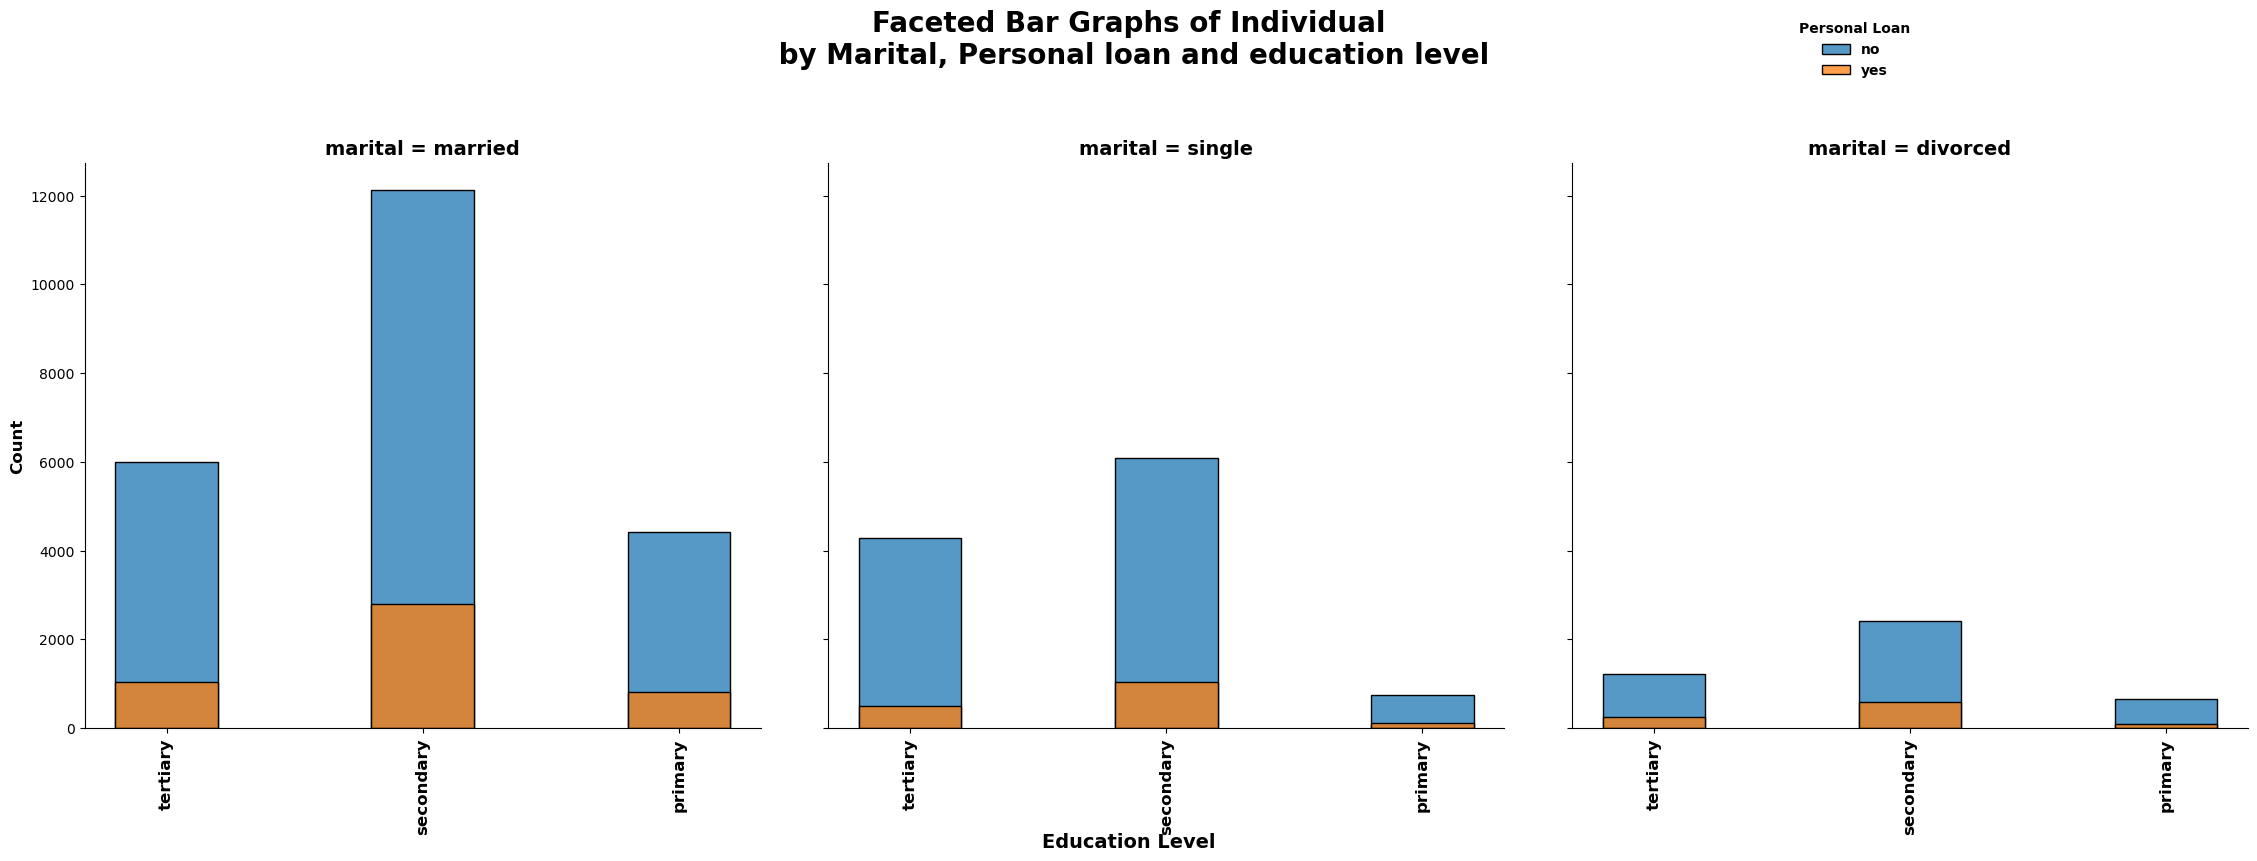

In [13]:
new_df = df.copy()
new_df['education_new'] = new_df['education'].replace('unknown', new_df['education'].mode()[0])
# FacetGrid : col = Marital status, hue = personal loan
g = sns.FacetGrid(new_df, col='marital', hue='loan', height=8, aspect=0.9, margin_titles=True, sharey=True)

# loan-segmented education distribution
g.map_dataframe(sns.histplot, x='education_new', multiple='stack', shrink=0.4)

# Rotate x-ticks
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation =90, fontsize=12, fontweight='bold')

for ax in g.axes.flat: 
    ax.set_title(ax.get_title(), fontweight="bold", fontsize=14)
# Add legend and labels
g.add_legend(title='Personal Loan', bbox_to_anchor=(0.85, 1), frameon=False)
# Make legend text bold 
legend = g._legend 
for text in legend.get_texts(): 
    text.set_fontweight("bold") 
legend.get_title().set_fontweight("bold")
g.set_axis_labels("", "Count", fontsize=12, fontweight='bold')
g.fig.suptitle("Faceted Bar Graphs of Individual\n by Marital, Personal loan and education level", y=1.05, fontsize=20, fontweight='bold')

# Add a common x-axis label for the whole figure 
g.fig.text(0.5, 0.01, "Education Level", ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()

From the faceted bar chart of education by marital status, we observe that most clients are married, followed by single, and then divorced. Married individuals are generally considered as having the most stable incomes, with single working individuals next, and divorced clients showing comparatively less stability. Regardless of all marital groups, secondary education is the most common, followed by tertiary and primary education. Additionally, the vast majority of clients have not taken personal loans.

Taken together, these patterns suggest that financial institutions tend to focus on clients who demonstrate the greatest stability—those most likely to be financially capable of making deposits. The ideal target group, as highlighted by the chart, consists of married individuals with at least secondary education and no personal loans.

Because the bank aims to grow deposit subscriptions, we explored personal finance features — age, balance, default, and housing. Age was added to the analysis to capture its effect, as it often shapes financial behavior.

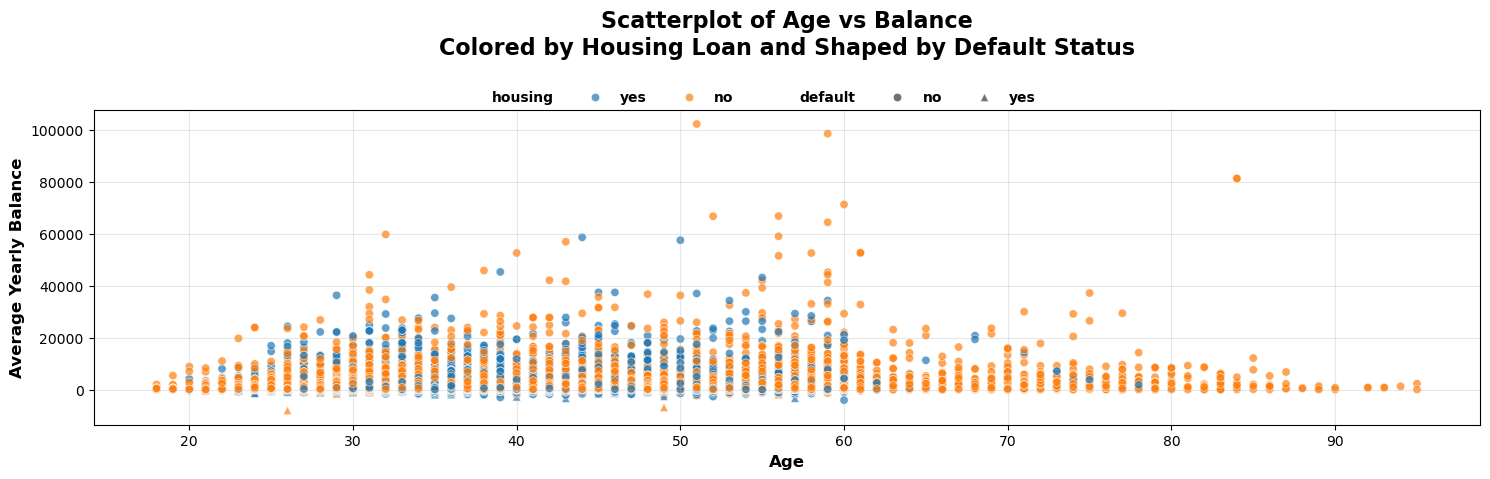

In [14]:
plt.figure(figsize=(15,5))
sns.scatterplot(
    data=new_df,
    x="age",
    y="balance",
    hue="housing",          # color by housing loan
    style="default",        # shape by default status
    markers={"no": "o", "yes": "^"},  # custom shapes
    #palette={"yes": "orange", "no": "skyblue"},  # custom colors
    alpha=0.7
)

# Labels and title
plt.xlabel("Age", fontsize=12, fontweight="bold")
plt.ylabel("Average Yearly Balance", fontsize=12, fontweight="bold")
plt.title("Scatterplot of Age vs Balance\nColored by Housing Loan and Shaped by Default Status",
          fontsize=16, fontweight="bold", y=1.15)

# Legend styling
legend = plt.legend(fontsize=10, title_fontsize=11, bbox_to_anchor=(0.25, 1.10), loc="upper left", ncol=6, frameon=False)
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_title().set_fontweight("bold")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


From the scatterplot, we can observe that most of the client neither have housing loan nor credit in default. It's evident that most of clients age falls within the range of 25 to 60 with average yearly balance < 20000 euros. Interestingly, we can obsereve that many clients with little to no balance (balance=0) at every age. 
This plot indicate that the bank was approaching peoplw with lower financial stability but not at a risk of defaulting.


**The bank’s target clients appear to be individuals with relatively modest incomes but who demonstrate financial, employment, and marital stability. This combination suggests they not only have the capacity to make deposits but also the motivation or need to do so.**

---


2. **What kind of clients tend to subscribe more often to a term deposit?**

Having identified the kinds of clients banks reach out to, the next step is to examine who is most likely to subscribe to term deposits.
As an initial step in the analysis, we examine the distribution of term deposit subscriptions across different job categories. This relationship is illustrated through a bar graph, which provides a clear visualization of how subscription rates vary by occupational group.

**Metric** : __Raw Count__ computed by largest contributers to subscription or which group give us most subscribers?
    
-  Raw Count shows where the volume comes from.

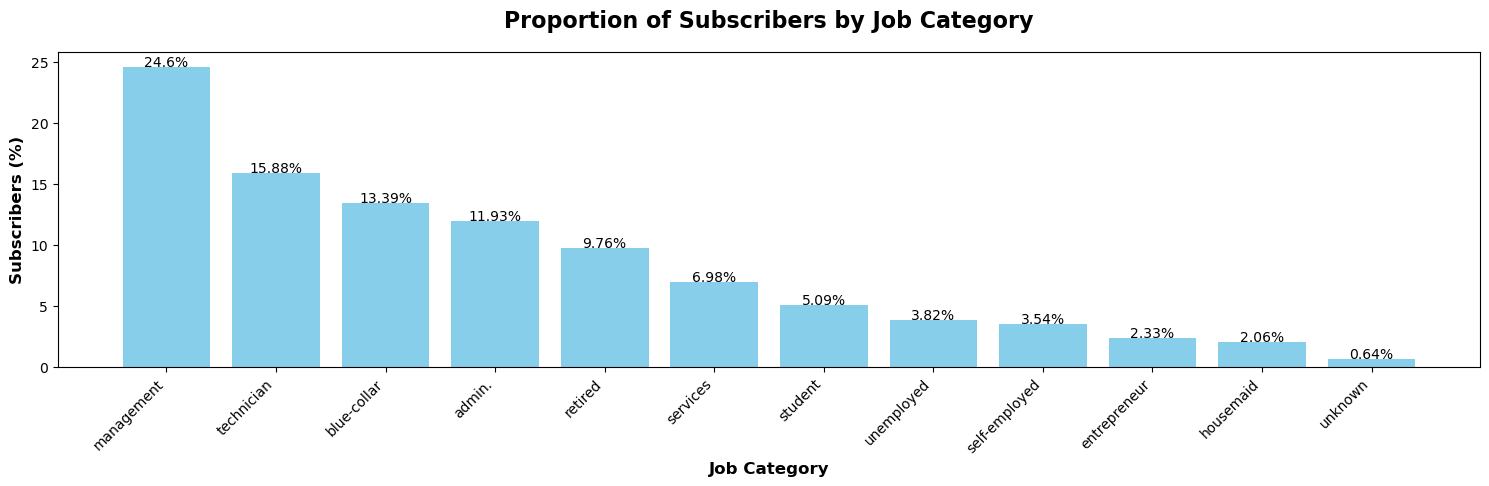

In [15]:

# Count subscribers ("yes") per job
job_subscribers = (
    df[df["y"] == "yes"]
    .groupby("job")
    .size()
    .reset_index(name="subscribers")
)

# Proportion of subscribers per job (percentage of total subscribers)
job_subscribers["proportion (%)"] = (
    job_subscribers["subscribers"] / job_subscribers["subscribers"].sum() * 100
).round(2)
job_subscribers = job_subscribers.sort_values(by="proportion (%)", ascending=False).reset_index(drop=True)


# --- Plot ---
plt.figure(figsize=(15,5))
plt.bar(job_subscribers["job"], job_subscribers["proportion (%)"], color="skyblue")
# Add text labels on top of the bars
for i, row in job_subscribers.iterrows():
    plt.text(i, row["proportion (%)"]+0.05, f"{row['proportion (%)']}%", ha="center", fontsize=10)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Job Category", fontsize=12, fontweight="bold")
plt.ylabel("Subscribers (%)", fontsize=12, fontweight="bold")
plt.title("Proportion of Subscribers by Job Category",fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


From the plot, it is evident that the most common job among clients who subscribed to term deposits was **management**, accounting for approximately 25% of all subscribers. The second most frequent category was **technician**, representing about 16% of subscribers. In contrast, the least represented groups were **entrepreneurs and housemaids**, as well as those whose occupation was recorded as **unknown**. These findings are consistent with expectations, since occupations such as management and technician are generally associated with greater financial stability and higher salaries, making individuals in these groups more likely to invest in term deposits.

In addition to job type, we can also examine how client age varies between those who subscribed and those who did not, considering both the overall age distribution and the age distributions segmented by marital status.

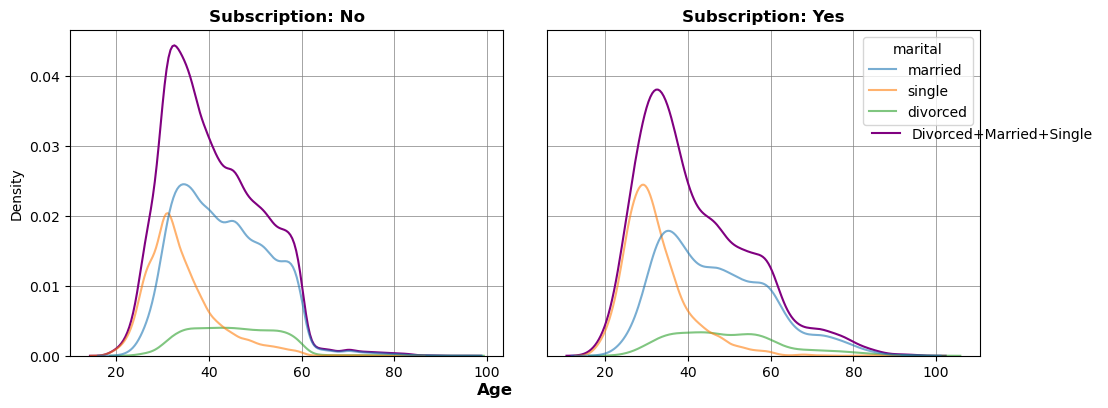

In [27]:
subs_category = new_df['y'].unique()
fig, axes = plt.subplots(1, len(subs_category), figsize=(10, 4), sharey=True)

for i, cat in enumerate(subs_category):
    ax = axes[i]
    sub = new_df[new_df['y'] == cat]

    # Overall age distribution (black line)
    sns.kdeplot(data=sub, x='age', fill=False, ax=ax, color='purple', label="Divorced+Married+Single")

    # Age distribution by marital status
    sns.kdeplot(data=sub, x='age', hue='marital', fill=False, ax=ax, alpha=0.6)


    # Formatting
    ax.set_title(f"Subscription: {cat.capitalize()}", fontsize=12, fontweight="bold")
    
    ax.set_xlabel('')
    ax.grid(color='gray', lw=0.5, ls='-')
    
    if i != 0:
        ax.tick_params(axis='y', left=False, labelleft=False)
    if i ==0:
        ax.legend().set_visible(False)
    
# Shared x-axis label
fig.text(0.5, 0.01, "Age", ha='center', va='center', fontsize=12, fontweight='bold')

# Collect handles/labels from one subplot and place legend globally
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.11, 0.7), ncol=3, frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()

Using this plot, we can begin by comparing the age distributions of subscribers and non‑subscribers across all clients, without considering marital status. Will compare this by 3 methods : KDE peaks, descriptive statistics and statistically.

- __KDE Peaks__

In [ ]:
# Comapring peaks numerically of age (subscribed vs not subscribed) using KDE peaks
subscribed = df[df['y'] == 'yes']['age']
not_subscribed = df[df['y'] == 'no']['age']
from scipy.stats import gaussian_kde

# KDE for smooth density
kde_sub = gaussian_kde(subscribed)
kde_non = gaussian_kde(not_subscribed)

x = np.linspace(min(df['age']), max(df['age']), 1000)
peak_sub = x[np.argmax(kde_sub(x))]
peak_non = x[np.argmax(kde_non(x))]

print("Peak age (Subscribed):", peak_sub.round(2))
print("Peak age (Not Subscribed):", peak_non.round(2))

# Compute difference between peaks
difference = abs(peak_sub - peak_non)
print("Difference:", difference.round(2))


# Compare to standard deviations of each group
std_sub = subscribed.std()
std_non = not_subscribed.std()

print("Std (Subscribed):", np.round(std_sub,2))
print("Std (Not Subscribed):", np.round(std_non,2))

# Rule of thumb: difference < 0.5 * average std → similar peaks
avg_std = (std_sub + std_non) / 2
if difference < 0.5 * avg_std:
    print("Peaks are similar")
else:
    print("Peaks are different")



Peak age (Subscribed): 32.57
Peak age (Not Subscribed): 32.49
Difference: 0.08
Std (Subscribed): 13.5
Std (Not Subscribed): 10.17
Peaks are similar


**Check Numerically: Are subscribers older on average than non-subscribers? Let's check the descriptive statistics of age by subscription status.**

In [ ]:
# Are subscribers older on average than non-subscribers? Let's check the descriptive statistics of age by subscription status.
df.groupby('y')['age'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,40.84,10.17,18.0,33.0,39.0,48.0,95.0
yes,5289.0,41.67,13.50,18.0,31.0,38.0,50.0,95.0


In [86]:
# Numerically: Are the ranges and percentiles wider?(tails)


print("Range (Subscribed):", subscribed.max() - subscribed.min())
print("Range (Not Subscribed):", not_subscribed.max() - not_subscribed.min())

print("Subscribed std:", np.round(subscribed.std(), 2))
print("Not subscribed std:", np.round(not_subscribed.std(), 2))


Range (Subscribed): 77
Range (Not Subscribed): 77
Subscribed std: 13.5
Not subscribed std: 10.17


- Larger range or std → wider distribution.

- If subscribers have higher values, it supports the idea of a broader age spread.

**Tail Quantiles**

In [84]:
print("Subscribed 95th percentile:", np.percentile(subscribed, 95))
print("Not subscribed 95th percentile:", np.percentile(not_subscribed, 95))

print("Subscribed 5th percentile:", np.percentile(subscribed, 5))
print("Not subscribed 5th percentile:", np.percentile(not_subscribed, 5))


Subscribed 95th percentile: 68.0
Not subscribed 95th percentile: 58.0
Subscribed 5th percentile: 25.0
Not subscribed 5th percentile: 27.0


- If the 95th percentile is higher for subscribers, their upper tail extends further.

- If the 5th percentile is lower, their lower tail extends further.

Together, this shows whether subscribers span a wider age range.

From the above analysis, we can conclude that peaks of these distributions are similar. The distribution for subscribers appears to peak at a slightly higher age, indicating that clients who choose to subscribe to term deposits tend to be somewhat older than those who do not.Moreover, the tails of the two distributions differ: the subscriber distribution extends more broadly, suggesting that clients who subscribe to term deposits span a wider and older age range compared to non‑subscribers.

Will perform statistical tests to validate these findings.

**Statistical Test** : is the distribution simiar? (Kolmogorov-Smirnov test)

3. **How successful are bank telemarketing campaigns based on contact communication type?**

We aim to evaluate the impact of the bank’s telemarketing campaign by analyzing the key features tied to its strategies and results.

__Contact communication type columns are considered__ : contact, duration and y (subscription status) for evaluating the impact of communication type on subscription status.

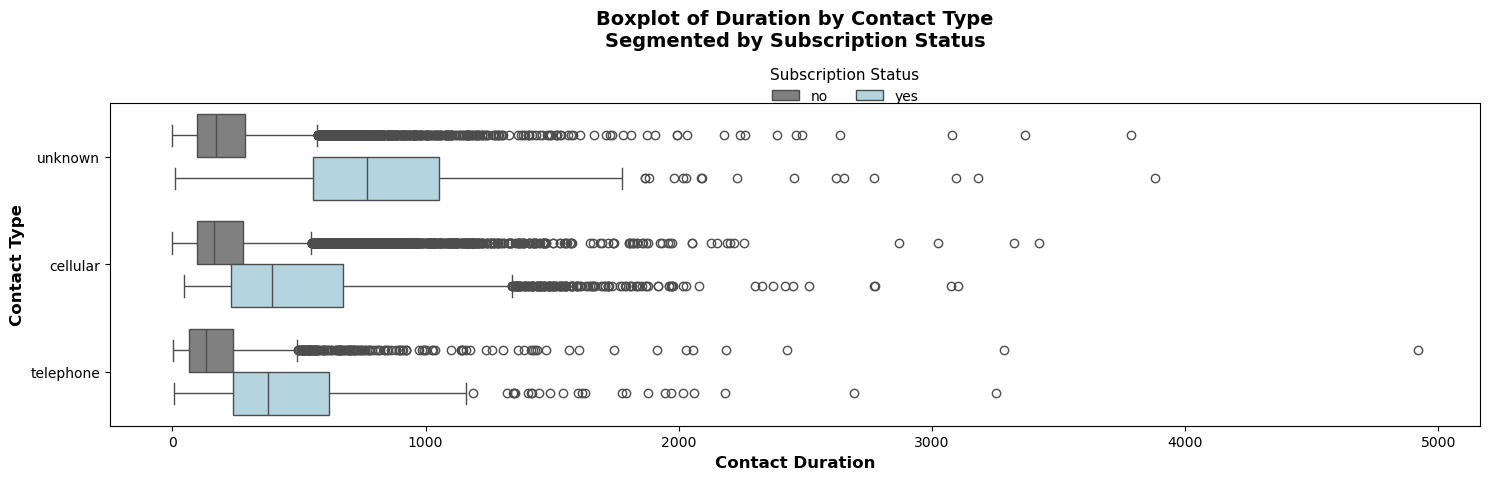

In [21]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(new_df, 
            x='duration', y='contact',
            hue='y', palette={'yes': 'lightblue', 'no': 'grey'})
plt.title("Boxplot of Duration by Contact Type\nSegmented by Subscription Status", fontsize=14, fontweight='bold', y=1.15)
plt.xlabel("Contact Duration", fontsize=12, fontweight='bold')
plt.ylabel("Contact Type", fontsize=12, fontweight='bold')

plt.legend(title='Subscription Status', title_fontsize=11 ,loc='upper right', bbox_to_anchor=(0.6, 1.15), ncol=3, frameon=False)
plt.tight_layout()
plt.show()